In [126]:
# libraries importation

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import re
from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import FunctionTransformer
from sklearn.impute import KNNImputer

import xgboost as xgb
import lightgbm as lgb

In [127]:
# Dataset importation

uploaded = files.upload()  # Choose the file: "Engine Data ML Project.xlsx"

# implement dataset
df = pd.read_excel("Engine Data ML Project.xlsx")
print("Data loaded successfully:", df.shape)
df.head()

Saving Engine Data ML Project.xlsx to Engine Data ML Project (4).xlsx
Data loaded successfully: (1737, 1024)


,id,Title,production years,"displacement, cc",fuel system,"power output, hp","torque output, nm",cylinder block,block head,"cylinder bore, mm",...,"power output, hp (kw)",28,"fuel consumption, l//100 km (for gas-3309)","oil change interval, hours",vehicle designation,xx.480,xx.540,11,265,"power output, kw / hp"
0,1,Engine Audi BDW,2004-2008,2393,distributed injection,177,230,aluminum v6,aluminum 24v,81,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,Engine Audi AUK,2004-2010,3123,direct injection,256,330,aluminum v6,aluminum 24v,84.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,Engine Audi BDX,2006-2010,2773,direct injection,210,280,aluminum v6,aluminum 24v,84.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,Engine Audi CAJA,2008-2011,2995,direct injection,290,420,aluminum v6,aluminum 24v,84.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,Engine Audi CGWA,2009-2013,2995,direct injection,290,420,aluminum v6,aluminum 24v,84.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


##1. Descriptive analysis of the data

### This first step is to explore and understand the dataset.
### We start by checking the shape of the data, column types, and missing values to identify potential quality issues.
### We then analyze summary statistics and visualize correlations between numeric variables to try to detect any relationships.
### This analysis helps us identify which features are relevant and whether the dataset is suitable for the project.

Dataset overview (before pre-processing) :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1737 entries, 0 to 1736
Columns: 1024 entries, id to power output, kw / hp
dtypes: float64(76), int64(1), object(947)
memory usage: 13.6+ MB

Percentage of missing values:


,0
315,99.942429
power output hp at rpm,99.942429
310 / 2300,99.942429
140 (103) / 2700,99.942429
160 (118) / 2500,99.942429
183 (136) / 2500,99.942429
200 (147) / 2700,99.942429
140 (103) / 2500,99.942429
185 (136) / 2500,99.942429
"dimensions, m (lxwxh)",99.942429


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,1737.0,NaN,NaN,NaN,869.0,501.573026,1.0,435.0,869.0,1303.0,1737.0
Title,1737,1737,Engine Peugeot TU5JP,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
production years,1561,522,since 2015,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"displacement, cc",1668.0,519.0,1998.0,90.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fuel system,1586,51,distributed injection,407,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
xx.480,1,1,353 kw,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
xx.540,1,1,397 kw,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11,1,1,"total working volume, dm3.",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
265,1,1,"engine power, kw &#8211; 265",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN


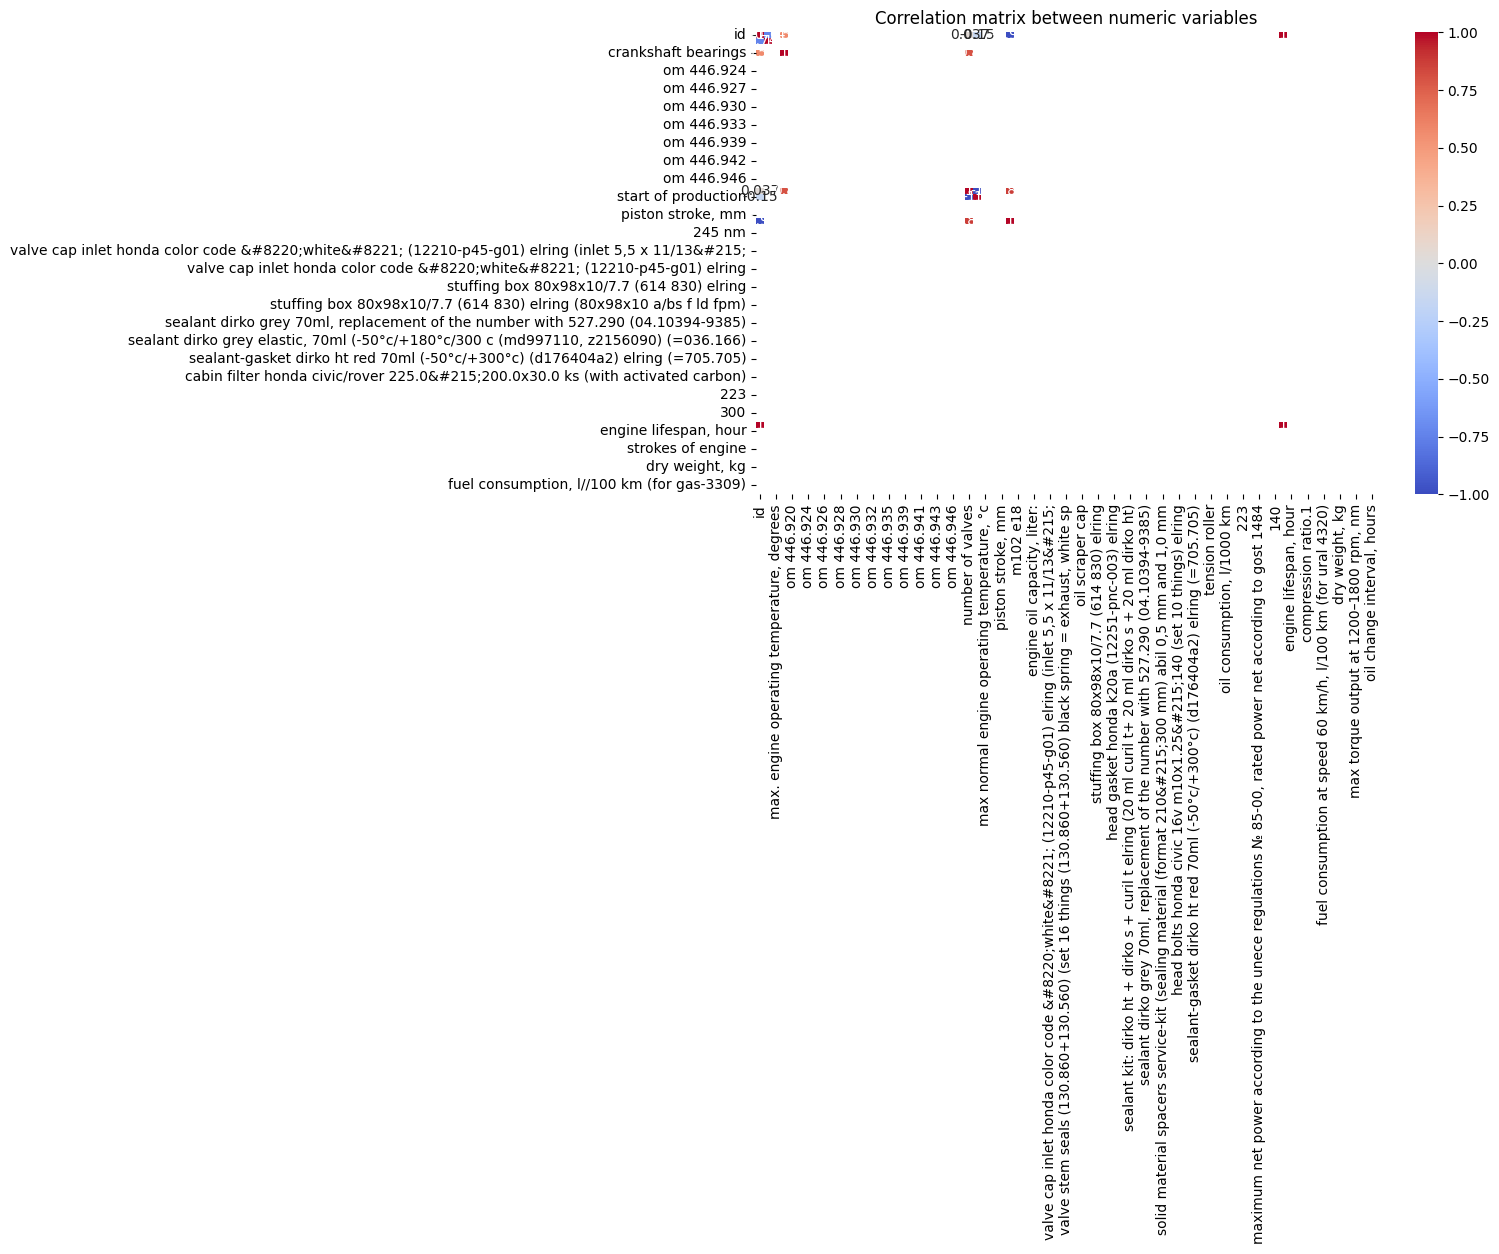

In [128]:
# General information (before pre-processing)
print("Dataset overview (before pre-processing) :")
df.info()

# Missing value analysis
print("\nPercentage of missing values:")
missing = df.isna().mean().sort_values(ascending=False) * 100
display(missing.head(20))

# Summary statistics for numeric columns
display(df.describe(include='all').T)

# Correlation heatmap (only for numeric columns)
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm')
plt.title("Correlation matrix between numeric variables")
plt.show()



### The results shown above are not satisfying aat all. There is a lot of missing values and unrelevant columns for us.
### We of course need to pre-process the data to keep only what we be useful. We will try to visualize this again after the pre-processing.
### Let's clean the dataset.


In [129]:
# Clean numeric values (extract digits only)
num_cols = [
    'displacement, cc', 'power output, hp', 'torque output, nm',
    'cylinder bore, mm', 'piston stroke, mm', 'compression ratio',
    'engine oil capacity, liter', 'engine lifespan, km', 'weight, kg'
]
df = df[[col for col in num_cols if col in df.columns]]
for col in num_cols:
    if col in df.columns:
        df[col] = (
            df[col]
            .astype(str)
            .str.extract(r'(\d+\.?\d*)')[0]
            .astype(float)
        )

# Extracts start and end years from the 'production years' string.
def extract_years(value):

    if pd.isna(value):
        return np.nan, np.nan

    text = str(value).lower()

    # Match ranges like '2004-2010'
    range_match = re.findall(r'(\d{4})\D+(\d{4})', text)
    if range_match:
        start, end = map(int, range_match[0])
        return start, end

    # Match 'since 2017'
    since_match = re.findall(r'since\s*(\d{4})', text)
    if since_match:
        start = int(since_match[0])
        end = np.nan
        return start, end

    # Match single year (e.g. '2009')
    single_match = re.findall(r'(\d{4})', text)
    if single_match:
        start = int(single_match[0])
        return start, np.nan

    return np.nan, np.nan


# Apply extraction to the dataset
if 'production years' in df.columns:
    df[['production_start', 'production_end']] = df['production years'].apply(lambda x: pd.Series(extract_years(x)))

    # Compute production span (if both years exist)
    df['production_span'] = df['production_end'] - df['production_start']

    # Drop the original text column
    df.drop(columns=['production years'], inplace=True)

# Remove rows without power or torque
df = df.dropna(subset=['power output, hp', 'torque output, nm'], how='all')

# Identify numeric and categorical columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [col for col in df.columns if col not in numeric_cols + ['id', 'Title']]

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

# Encode categorical variables using one-hot encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("Preprocessed dataset shape:", df_encoded.shape)
df_encoded.head()


Numeric columns: ['displacement, cc', 'power output, hp', 'torque output, nm', 'cylinder bore, mm', 'piston stroke, mm', 'compression ratio', 'engine oil capacity, liter', 'engine lifespan, km', 'weight, kg']
Categorical columns: []
Preprocessed dataset shape: (1346, 9)


,"displacement, cc","power output, hp","torque output, nm","cylinder bore, mm","piston stroke, mm",compression ratio,"engine oil capacity, liter","engine lifespan, km","weight, kg"
0,2393.0,177.0,230.0,81.0,77.4,10.3,6.5,280.0,NaN
1,3123.0,256.0,330.0,84.5,92.8,12.5,6.5,260.0,NaN
2,2773.0,210.0,280.0,84.5,82.4,12.0,6.2,250.0,NaN
3,2995.0,290.0,420.0,84.5,89.0,10.5,6.5,250.0,NaN
4,2995.0,290.0,420.0,84.5,89.0,10.5,6.5,240.0,NaN


### Now the dataset is cleaned and we kept only the columns that we want for the project.
### Let's try to analyze the data again.

Dataset overview (after pre-processing):
<class 'pandas.core.frame.DataFrame'>
Index: 1346 entries, 0 to 1736
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   displacement, cc            1344 non-null   float64
 1   power output, hp            1329 non-null   float64
 2   torque output, nm           1259 non-null   float64
 3   cylinder bore, mm           1344 non-null   float64
 4   piston stroke, mm           1344 non-null   float64
 5   compression ratio           1309 non-null   float64
 6   engine oil capacity, liter  1270 non-null   float64
 7   engine lifespan, km         1268 non-null   float64
 8   weight, kg                  909 non-null    float64
dtypes: float64(9)
memory usage: 105.2 KB

Percentage of missing values:


,0
"weight, kg",32.466568
"torque output, nm",6.463596
"engine lifespan, km",5.794948
"engine oil capacity, liter",5.646360
compression ratio,2.748886
"power output, hp",1.263001
"displacement, cc",0.148588
"piston stroke, mm",0.148588
"cylinder bore, mm",0.148588


,count,mean,std,min,25%,50%,75%,max
"displacement, cc",1344.0,2566.609375,2120.754454,659.0,1598.0,1997.0,2522.0,24240.0
"power output, hp",1329.0,168.939052,101.505935,35.0,105.0,145.0,204.0,1900.0
"torque output, nm",1259.0,258.696585,157.338456,55.0,165.0,230.0,320.0,3550.0
"cylinder bore, mm",1344.0,84.451927,10.424230,65.4,79.0,83.0,87.5,144.0
"piston stroke, mm",1344.0,88.299100,13.603758,62.0,81.9,86.0,92.4,166.0
compression ratio,1309.0,12.316173,3.786169,7.5,9.6,10.5,16.0,23.0
"engine oil capacity, liter",1270.0,5.110654,1.794029,2.5,4.0,4.6,5.8,30.0
"engine lifespan, km",1268.0,320.717666,675.070283,120.0,250.0,300.0,350.0,24000.0
"weight, kg",909.0,226.076898,620.517578,50.0,121.0,148.0,186.0,8211.0


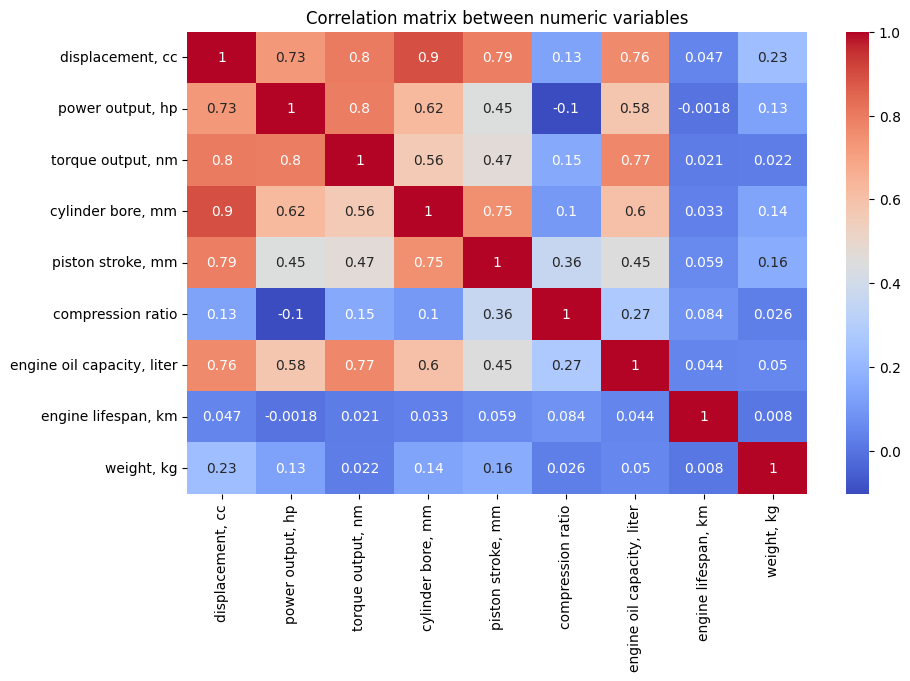

In [130]:
# General information (after pre-processing)
print("Dataset overview (after pre-processing):")
df.info()

# Missing value analysis
print("\nPercentage of missing values:")
missing = df.isna().mean().sort_values(ascending=False) * 100
display(missing.head(20))

# Summary statistics for numeric columns
display(df.describe(include='all').T)

# Correlation heatmap (only for numeric columns)
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm')
plt.title("Correlation matrix between numeric variables")
plt.show()

### Thanks to the pre-processing, we can analyse the dataset.
### We reduced the number of columns to a decent number of 23 instead of 1024. Almost every columns were in double and completely empty so useless for the project.
### We still have a lot of missing values, we will fix that later after a first test of model.

### Now that the data is cleaned, We will define the problem clearly.
### The main goal is to predict the output power (Horsepower) and torque (Newton/meters) according to the specifications of the engine.
### This can be very useful for engine engineers because they can predict aproximately the power delivered by the engine even before testing it in real life.
### In order to do this, we will train a model with the data we just cleaned, including both numerical and categorical data.
### Our next step is to start a besline model and see what can he do. This will be our baseline for the project that we will try to improve to make it the most accurate.


In [131]:
# Features (X) and targets (Y)
X = df_encoded.drop(['power output, hp', 'torque output, nm'], axis=1)
Y = df_encoded[['power output, hp', 'torque output, nm']]

# Split into training (80%) and test(20%) sets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("Y_train shape:", Y_train.shape)

X_train shape: (1076, 7)
Y_train shape: (1076, 2)


In [132]:
# Initialize a multi-output model
imputer_y = SimpleImputer(strategy='mean')
Y_train_imputed = imputer_y.fit_transform(Y_train)
Y_test_imputed = imputer_y.transform(Y_test)

imputer_x = SimpleImputer(strategy='mean')

# Create a pipeline for the base estimator that includes imputation for X features
base_estimator = make_pipeline(imputer_x, RandomForestRegressor(n_estimators=100, random_state=42))

# Train the multi-output model
model = MultiOutputRegressor(base_estimator)
model.fit(X_train, Y_train_imputed)

# Predict on the test set
Y_pred = model.predict(X_test)

# Evaluate the model using the imputed Y_test
mae = mean_absolute_error(Y_test_imputed, Y_pred)
mse = mean_squared_error(Y_test_imputed, Y_pred)
r2 = r2_score(Y_test_imputed, Y_pred)

print("Baseline model performance:")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R² Score: {r2:.3f}")

Baseline model performance:
Mean Absolute Error (MAE): 33.24
Mean Squared Error (MSE): 6094.16
R² Score: 0.624


###The results are accepetable for now, it shows that the project is viable and the data allows us to perform some prediction.
###However, we will try to achieve an R2 score of at least 0.9, and reduced as much as possible the error.
### Let's plot the results to visualize them.

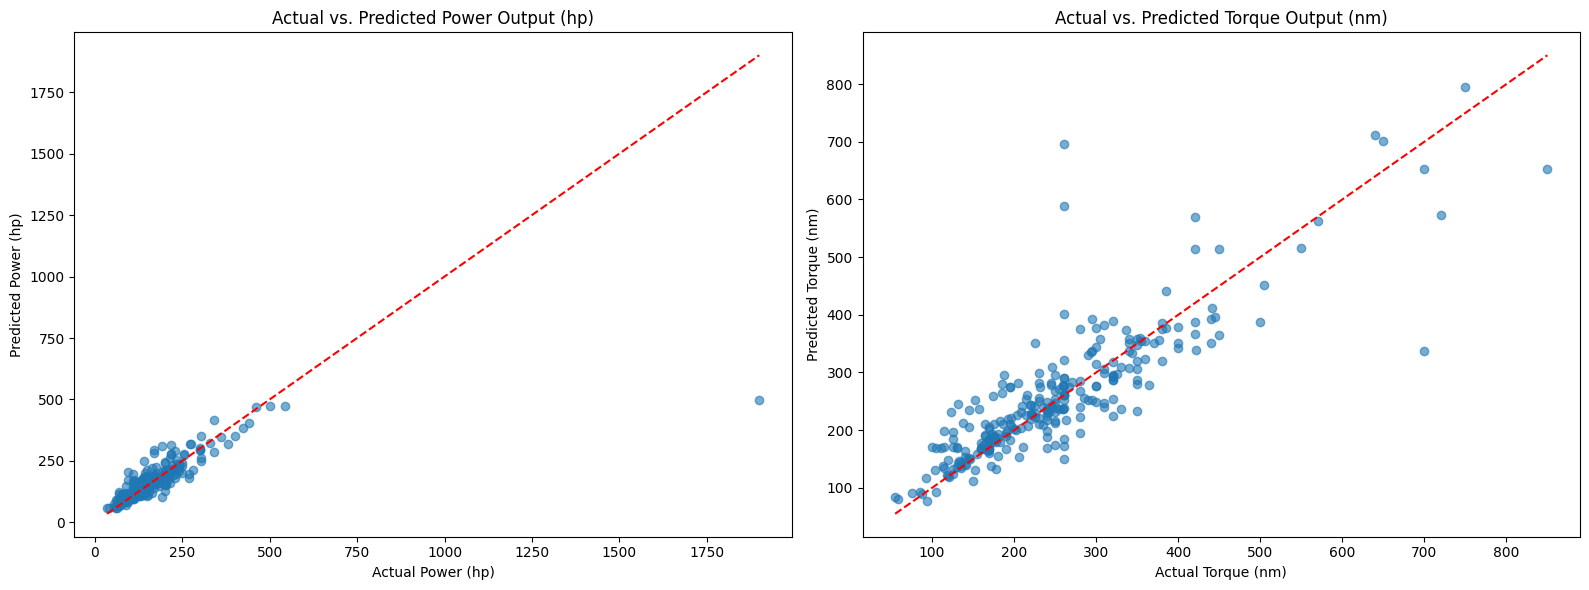

In [133]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot for Power Output (hp)
actual_power = Y_test_imputed[:, 0]
predicted_power = Y_pred[:, 0]

axes[0].scatter(actual_power, predicted_power, alpha=0.6)
axes[0].set_title('Actual vs. Predicted Power Output (hp)')
axes[0].set_xlabel('Actual Power (hp)')
axes[0].set_ylabel('Predicted Power (hp)')

# Add a diagonal line for perfect predictions
min_val_power = min(actual_power.min(), predicted_power.min())
max_val_power = max(actual_power.max(), predicted_power.max())
axes[0].plot([min_val_power, max_val_power], [min_val_power, max_val_power], color='red', linestyle='--')

# Plot for Torque Output (nm)
actual_torque = Y_test_imputed[:, 1]
predicted_torque = Y_pred[:, 1]

axes[1].scatter(actual_torque, predicted_torque, alpha=0.6)
axes[1].set_title('Actual vs. Predicted Torque Output (nm)')
axes[1].set_xlabel('Actual Torque (nm)')
axes[1].set_ylabel('Predicted Torque (nm)')

# Add a diagonal line for perfect predictions
min_val_torque = min(actual_torque.min(), predicted_torque.min())
max_val_torque = max(actual_torque.max(), predicted_torque.max())
axes[1].plot([min_val_torque, max_val_torque], [min_val_torque, max_val_torque], color='red', linestyle='--')

plt.tight_layout()
plt.show()

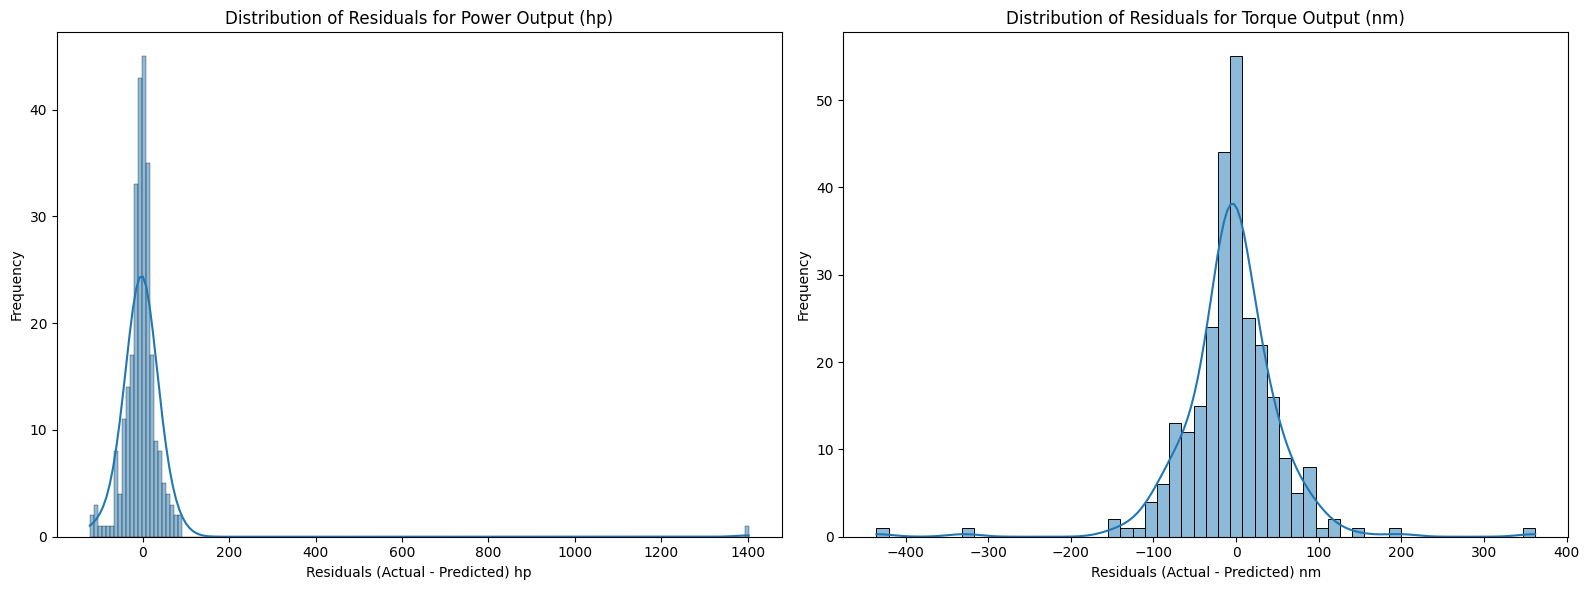

In [134]:
residuals_power = actual_power - predicted_power
residuals_torque = actual_torque - predicted_torque

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram for Power Output Residuals
sns.histplot(residuals_power, kde=True, ax=axes[0])
axes[0].set_title('Distribution of Residuals for Power Output (hp)')
axes[0].set_xlabel('Residuals (Actual - Predicted) hp')
axes[0].set_ylabel('Frequency')

# Histogram for Torque Output Residuals
sns.histplot(residuals_torque, kde=True, ax=axes[1])
axes[1].set_title('Distribution of Residuals for Torque Output (nm)')
axes[1].set_xlabel('Residuals (Actual - Predicted) nm')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

###In these plots, we want to find the most values possible close to the red line.
###Those plots show us that the predictions for the power are acceptable but we still have one value very far and weird. For the torque, the predictions seem less acurate. We will try to improve that.



###In order to improve our results, we will try to improve the quality of the data. We will process it in a better way than before.
### Then, we will implement new types of models to achieve a better accuracy.



In [135]:
df_full = pd.read_excel("Engine Data ML Project.xlsx")

# Select a comprehensive set of relevant columns
useful_cols = [
    'id', 'Title', 'production years', 'displacement, cc', 'fuel system',
    'power output, hp', 'torque output, nm', 'cylinder block', 'block head',
    'cylinder bore, mm', 'piston stroke, mm', 'compression ratio',
    'features', 'hydraulic lifters', 'timing drive', 'phase regulator',
    'turbocharging', 'recommended engine oil', 'engine oil capacity, liter',
    'fuel type', 'euro standards', 'engine lifespan, km', 'weight, kg'
]

df_processed = df_full[[col for col in useful_cols if col in df_full.columns]].copy()

print("Original dataset shape:", df_full.shape)
print("Processed dataset shape after column selection:", df_processed.shape)
print("Columns selected:", df_processed.columns.tolist())


Original dataset shape: (1737, 1024)
Processed dataset shape after column selection: (1737, 23)
Columns selected: ['id', 'Title', 'production years', 'displacement, cc', 'fuel system', 'power output, hp', 'torque output, nm', 'cylinder block', 'block head', 'cylinder bore, mm', 'piston stroke, mm', 'compression ratio', 'features', 'hydraulic lifters', 'timing drive', 'phase regulator', 'turbocharging', 'recommended engine oil', 'engine oil capacity, liter', 'fuel type', 'euro standards', 'engine lifespan, km', 'weight, kg']


In [136]:
def extract_years(value):
    if pd.isna(value):
        return np.nan, np.nan

    text = str(value).lower()

    range_match = re.findall(r'(\d{4})\D+(\d{4})', text)
    if range_match:
        start, end = map(int, range_match[0])
        return start, end

    since_match = re.findall(r'since\s*(\d{4})', text)
    if since_match:
        start = int(since_match[0])
        return start, np.nan

    single_match = re.findall(r'(\d{4})', text)
    if single_match:
        start = int(single_match[0])
        return start, np.nan

    return np.nan, np.nan

df_processed[['production_start', 'production_end']] = df_processed['production years'].apply(lambda x: pd.Series(extract_years(x)))

df_processed['production_span'] = df_processed['production_end'] - df_processed['production_start']
df_processed['production_mid_year'] = df_processed[['production_start', 'production_end']].mean(axis=1)

current_year = 2024
df_processed['engine_age'] = current_year - df_processed['production_start']

df_processed.drop(columns=['production years'], inplace=True)

print("DataFrame after production years processing:")
df_processed.head()

DataFrame after production years processing:


,id,Title,"displacement, cc",fuel system,"power output, hp","torque output, nm",cylinder block,block head,"cylinder bore, mm","piston stroke, mm",...,"engine oil capacity, liter",fuel type,euro standards,"engine lifespan, km","weight, kg",production_start,production_end,production_span,production_mid_year,engine_age
0,1,Engine Audi BDW,2393,distributed injection,177,230,aluminum v6,aluminum 24v,81,77.4,...,6.5,petrol,euro 4,~280 000,NaN,2004.0,2008.0,4.0,2006.0,20.0
1,2,Engine Audi AUK,3123,direct injection,256,330,aluminum v6,aluminum 24v,84.5,92.8,...,6.5,petrol,euro 4,~260 000,NaN,2004.0,2010.0,6.0,2007.0,20.0
2,3,Engine Audi BDX,2773,direct injection,210,280,aluminum v6,aluminum 24v,84.5,82.4,...,6.2,petrol,euro 4,~250 000,NaN,2006.0,2010.0,4.0,2008.0,18.0
3,4,Engine Audi CAJA,2995,direct injection,290,420,aluminum v6,aluminum 24v,84.5,89,...,6.5,petrol,euro 5,~250 000,NaN,2008.0,2011.0,3.0,2009.5,16.0
4,5,Engine Audi CGWA,2995,direct injection,290,420,aluminum v6,aluminum 24v,84.5,89,...,6.5,petrol,euro 5,~240 000,NaN,2009.0,2013.0,4.0,2011.0,15.0



DataFrame after cleaning numeric columns and dropping rows with missing targets:
<class 'pandas.core.frame.DataFrame'>
Index: 1242 entries, 0 to 1736
Data columns (total 27 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          1242 non-null   int64  
 1   Title                       1242 non-null   object 
 2   displacement, cc            1241 non-null   float64
 3   fuel system                 1239 non-null   object 
 4   power output, hp            1242 non-null   float64
 5   torque output, nm           1242 non-null   float64
 6   cylinder block              1234 non-null   object 
 7   block head                  1239 non-null   object 
 8   cylinder bore, mm           1240 non-null   float64
 9   piston stroke, mm           1240 non-null   float64
 10  compression ratio           1238 non-null   float64
 11  features                    1125 non-null   object 
 12  hydraulic lif

,id,Title,fuel system,"power output, hp","torque output, nm",cylinder block,block head,"cylinder bore, mm","piston stroke, mm",compression ratio,...,"engine oil capacity, liter",fuel type,euro standards,"engine lifespan, km","weight, kg",production_start,production_end,production_span,production_mid_year,engine_age
0,1,Engine Audi BDW,distributed injection,177.0,230.0,aluminum v6,aluminum 24v,81.0,77.4,10.3,...,6.5,petrol,euro 4,280.0,NaN,2004.0,2008.0,4.0,2006.0,20.0
1,2,Engine Audi AUK,direct injection,256.0,330.0,aluminum v6,aluminum 24v,84.5,92.8,12.5,...,6.5,petrol,euro 4,260.0,NaN,2004.0,2010.0,6.0,2007.0,20.0
2,3,Engine Audi BDX,direct injection,210.0,280.0,aluminum v6,aluminum 24v,84.5,82.4,12.0,...,6.2,petrol,euro 4,250.0,NaN,2006.0,2010.0,4.0,2008.0,18.0
3,4,Engine Audi CAJA,direct injection,290.0,420.0,aluminum v6,aluminum 24v,84.5,89.0,10.5,...,6.5,petrol,euro 5,250.0,NaN,2008.0,2011.0,3.0,2009.5,16.0
4,5,Engine Audi CGWA,direct injection,290.0,420.0,aluminum v6,aluminum 24v,84.5,89.0,10.5,...,6.5,petrol,euro 5,240.0,NaN,2009.0,2013.0,4.0,2011.0,15.0



Percentage of missing values:


,0
"weight, kg",31.964573
production_end,24.476651
production_span,24.476651
features,9.420290
phase regulator,6.038647
"engine oil capacity, liter",1.690821
production_mid_year,1.529791
production_start,1.529791
engine_age,1.529791
recommended engine oil,1.368760


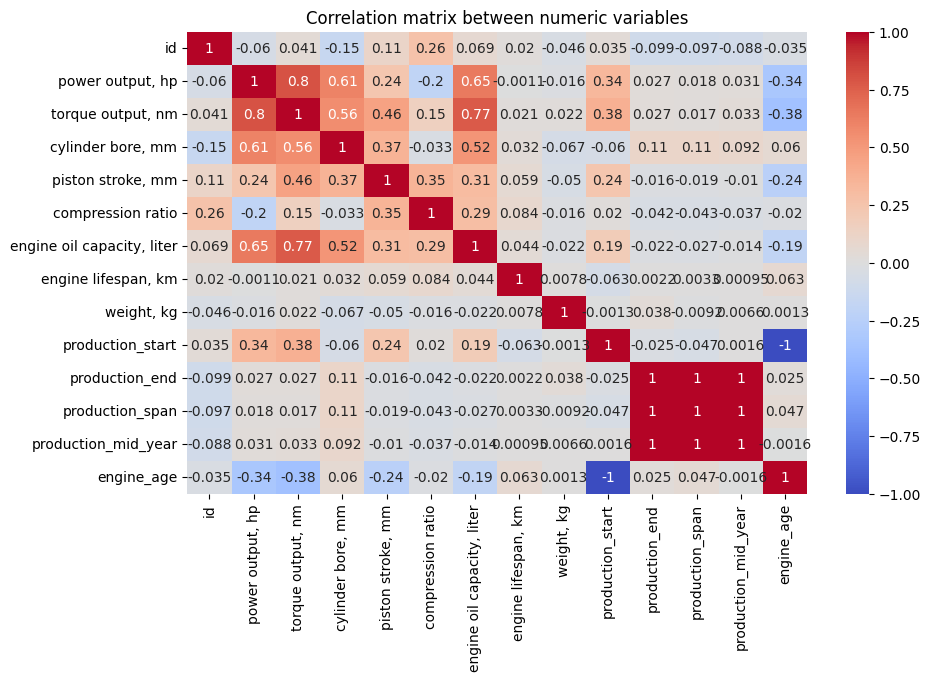

In [137]:
numeric_cols_to_clean = [
    'displacement, cc', 'power output, hp', 'torque output, nm',
    'cylinder bore, mm', 'piston stroke, mm', 'compression ratio',
    'engine oil capacity, liter', 'engine lifespan, km', 'weight, kg'
]

for col in numeric_cols_to_clean:
    if col in df_processed.columns:
        df_processed[col] = df_processed[col].astype(str).str.extract(r'([\d\.]+)')
        df_processed[col] = pd.to_numeric(df_processed[col], errors='coerce')

# Drop rows where 'power output, hp' or 'torque output, nm' are missing
df_processed.dropna(subset=['power output, hp', 'torque output, nm'], how='any', inplace=True)

print("\nDataFrame after cleaning numeric columns and dropping rows with missing targets:")
df_processed.info()
df_processed.drop(columns=['displacement, cc'], inplace=True)
df_processed.info()
print("\nDataFrame head:")
display(df_processed.head())

# Display missing value analysis
print("\nPercentage of missing values:")
missing_values = df_processed.isna().mean().sort_values(ascending=False) * 100
display(missing_values[missing_values > 0])

# Correlation matrix
plt.figure(figsize=(10,6))
sns.heatmap(df_processed.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm')
plt.title("Correlation matrix between numeric variables")
plt.show()

Features dropped due to high correlation (>95%): ['production_span', 'production_mid_year', 'engine_age']

Final number of numeric features: 9
Final number of categorical features: 12

Percentage of missing values:


,0
"weight, kg",31.964573
production_end,24.476651
features,9.420290
phase regulator,6.038647
"engine oil capacity, liter",1.690821
production_start,1.529791
recommended engine oil,1.368760
turbocharging,1.046699
hydraulic lifters,0.724638
cylinder block,0.644122


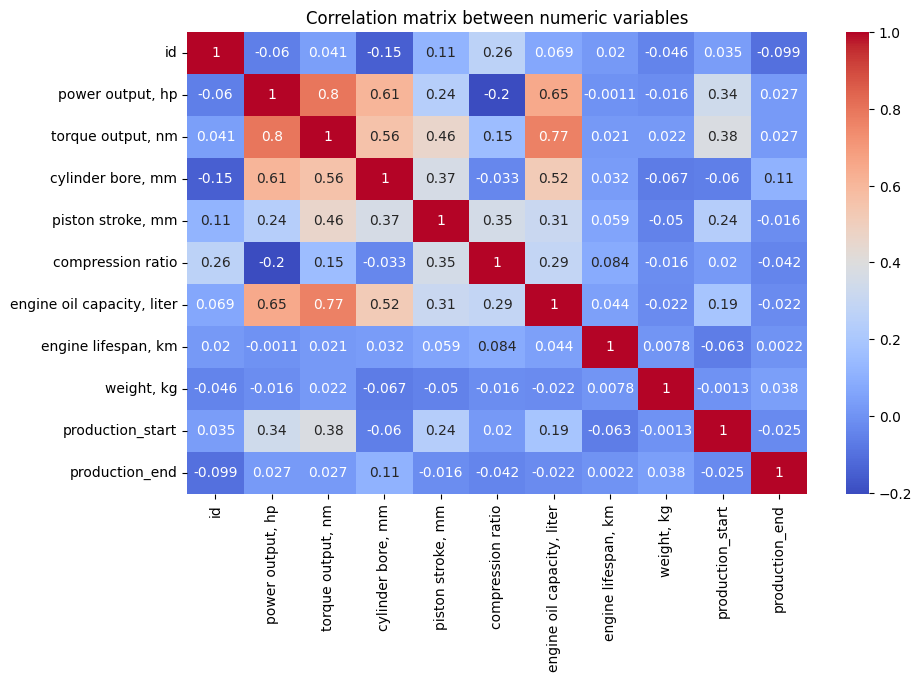

In [138]:
df_cleaning_step = df_processed.copy()

# Identify numeric columns
targets = ['power output, hp', 'torque output, nm']
numeric_cols_temp = df_cleaning_step.select_dtypes(include=['int64', 'float64']).columns.tolist()
features_to_check = [f for f in numeric_cols_temp if f not in targets]

# Calculate Correlation Matrix
corr_matrix = df_cleaning_step[features_to_check].corr().abs()

# Identify features with correlation > 0.95 (redundant)
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]

print(f"Features dropped due to high correlation (>95%): {to_drop}")

# Drop redundant features
df_final = df_cleaning_step.drop(columns=to_drop)

# Update feature lists for the Pipeline
numeric_features = df_final.select_dtypes(include=['int64', 'float64']).columns.tolist()
numeric_features = [f for f in numeric_features if f not in targets]

categorical_features = df_final.select_dtypes(include=['object']).columns.tolist()

print(f"\nFinal number of numeric features: {len(numeric_features)}")
print(f"Final number of categorical features: {len(categorical_features)}")

# Display missing value analysis
print("\nPercentage of missing values:")
missing_values = df_final.isna().mean().sort_values(ascending=False) * 100
display(missing_values[missing_values > 0])

# Correlation matrix
plt.figure(figsize=(10,6))
sns.heatmap(df_final.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm')
plt.title("Correlation matrix between numeric variables")
plt.show()

### We have just corrected the correlation matrix and we should have better and more accurate results. We need to correct the huge number of missing values. To do that, we will use a KNN imputer to fill the missing values with the median of 5 close values.

In [139]:

numeric_transformer = Pipeline(steps=[
    ('imputer', KNNImputer(n_neighbors=5))
])

categorical_transformer = Pipeline(steps=[
    ('string_converter', FunctionTransformer(lambda x: x.astype(str), validate=False)),
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    verbose_feature_names_out=False
).set_output(transform="pandas")

xgboost_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('multioutputregressor', MultiOutputRegressor(estimator=xgb.XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        random_state=42,
        n_jobs=-1
    )))
])

targets = ['power output, hp', 'torque output, nm']

X = df_final[numeric_features + categorical_features]
Y = df_final[targets]

imputer_y = SimpleImputer(strategy='median')
Y_imputed = pd.DataFrame(imputer_y.fit_transform(Y), columns=Y.columns)

X_train, X_test, Y_train, Y_test = train_test_split(X, Y_imputed, test_size=0.2, random_state=42)

xgboost_pipeline.fit(X_train, Y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   KNNImputer())]),
                                                  ['id', 'cylinder bore, mm',
                                                   'piston stroke, mm',
                                                   'compression ratio',
                                                   'engine oil capacity, liter',
                                                   'engine lifespan, km',
                                                   'weight, kg',
                                                   'production_start',
                                                   'production_end']),
                                                 ('cat',
                                                  Pipeline(steps=[('string_converter',
                                                                   FunctionTransformer(func=<function <l...
                                                             feature_weights=None,
                                                             gamma=None,
                                                             grow_policy=None,
                                                             importance_type=None,
                                                             interaction_constraints=None,
                                                             learning_rate=0.05,
                                                             max_bin=None,
                                                             max_cat_threshold=None,
                                                             max_cat_to_onehot=None,
                                                             max_delta_step=None,
                                                             max_depth=6,
                                                             max_leaves=None,
                                                             min_child_weight=None,
                                                             missing=nan,
                                                             monotone_constraints=None,
                                                             multi_strategy=None,
                                                             n_estimators=300,
                                                             n_jobs=-1,
                                                             num_parallel_tree=None, ...)))])

###Now that the data processing is better, we will try other models and try to improve the performance of our predictions.
### We will first try to tune the hyperparameters and optimize the random forest regressor. Then we use the feature engineering to improve the RF regressor. And finally, we will implement the HistGradient Boosting regressor.

In [140]:
# Tuned Random Forest Regressor
print("\n--- Tuned Random Forest Regressor ---")

full_rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('multioutputregressor', MultiOutputRegressor(estimator=RandomForestRegressor(random_state=42)))
])

param_grid = {
    'multioutputregressor__estimator__n_estimators': [50, 100, 150],
    'multioutputregressor__estimator__max_depth': [None, 10, 20],
    'multioutputregressor__estimator__min_samples_split': [2, 5]
}

# Initialize GridSearchCV
grid_search = GridSearchCV(
    estimator=full_rf_pipeline,
    param_grid=param_grid,
    cv=3,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=0
)

grid_search.fit(X_train, Y_train)

# Store the best model
best_model = grid_search.best_estimator_

# Predict on the test set using the best model
Y_pred_tuned = best_model.predict(X_test)

# Evaluate the tuned model
mae_tuned = mean_absolute_error(Y_test, Y_pred_tuned)
mse_tuned = mean_squared_error(Y_test, Y_pred_tuned)
r2_tuned = r2_score(Y_test, Y_pred_tuned)

print(f"Mean Absolute Error (MAE): {mae_tuned:.2f}")
print(f"Mean Squared Error (MSE): {mse_tuned:.2f}")
print(f"R² Score: {r2_tuned:.3f}")

# Tuned Random Forest Regressor with Feature Engineering (FE)
print("\n--- Tuned Random Forest Regressor + Feature Engineering ---")

X_fe_temp = X.copy()

if 'cylinder bore, mm' in X_fe_temp.columns and 'piston stroke, mm' in X_fe_temp.columns:
    X_fe_temp['bore_stroke_product'] = X_fe_temp['cylinder bore, mm'] * X_fe_temp['piston stroke, mm']

numeric_features_fe = [f for f in numeric_features]
new_fe_cols = []
if 'bore_stroke_product' in X_fe_temp.columns and 'bore_stroke_product' not in numeric_features_fe:
    numeric_features_fe.append('bore_stroke_product')
    new_fe_cols.append('bore_stroke_product')

# If no new features were actually added, just use the original preprocessor and data split
if not new_fe_cols:
    print("No new feature-engineered columns were effectively added or relevant for this model, reusing previous data split.")
    X_train_fe, X_test_fe = X_train, X_test
    fe_pipeline = best_model
else:
    print(f"Adding new engineered features: {new_fe_cols}")
    Y_imputed = pd.DataFrame(imputer_y.fit_transform(Y), columns=Y.columns)
    X_train_fe, X_test_fe, Y_train_fe, Y_test_fe = train_test_split(X_fe_temp, Y_imputed, test_size=0.2, random_state=42)

    preprocessor_fe = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numeric_features_fe),
            ('cat', categorical_transformer, categorical_features)
        ],
        verbose_feature_names_out=False
    ).set_output(transform="pandas")

    # Create a new pipeline for the FE model
    fe_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor_fe),
        ('multioutputregressor', MultiOutputRegressor(estimator=RandomForestRegressor(random_state=42)))
    ])
    fe_pipeline.fit(X_train_fe, Y_train_fe)

# Predict on the test set using the retrained model and feature-engineered test data
Y_pred_fe = fe_pipeline.predict(X_test_fe)

# Evaluate the model's performance
mae_fe = mean_absolute_error(Y_test_fe if new_fe_cols else Y_test, Y_pred_fe)
mse_fe = mean_squared_error(Y_test_fe if new_fe_cols else Y_test, Y_pred_fe)
r2_fe = r2_score(Y_test_fe if new_fe_cols else Y_test, Y_pred_fe)

print(f"Mean Absolute Error (MAE): {mae_fe:.2f}")
print(f"Mean Squared Error (MSE): {mse_fe:.2f}")
print(f"R² Score: {r2_fe:.3f}")

# HistGradientBoostingRegressor
print("\n--- HistGradientBoostingRegressor ---")

# Create a Pipeline that first applies the preprocessor and then trains the MultiOutputRegressor
pipeline_hgb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('multioutputregressor', MultiOutputRegressor(estimator=HistGradientBoostingRegressor(random_state=42)))
])

# Train the pipeline on the X_train and Y_train datasets
pipeline_hgb.fit(X_train, Y_train)

# Predict the 'power output, hp' and 'torque output, nm' for the X_test dataset
Y_pred_hgb = pipeline_hgb.predict(X_test)

# Evaluate the model's performance
mae_hgb = mean_absolute_error(Y_test, Y_pred_hgb)
mse_hgb = mean_squared_error(Y_test, Y_pred_hgb)
r2_hgb = r2_score(Y_test, Y_pred_hgb)

print(f"Mean Absolute Error (MAE): {mae_hgb:.2f}")
print(f"Mean Squared Error (MSE): {mse_hgb:.2f}")
print(f"R² Score: {r2_hgb:.3f}")



--- Tuned Random Forest Regressor ---
Mean Absolute Error (MAE): 20.64
Mean Squared Error (MSE): 1000.80
R² Score: 0.898

--- Tuned Random Forest Regressor + Feature Engineering ---
Adding new engineered features: ['bore_stroke_product']
Mean Absolute Error (MAE): 20.70
Mean Squared Error (MSE): 1022.66
R² Score: 0.896

--- HistGradientBoostingRegressor ---
Mean Absolute Error (MAE): 22.52
Mean Squared Error (MSE): 1375.36
R² Score: 0.873


###We can see some improvements compared to the baseline model but not as much as expected. I expect at least an R2 score of 0.9.
### We will now implement a new type of model, the XGBoost regressor model and lightGBM regressor and see if we can have even better results.

In [141]:
numeric_transformer = Pipeline(steps=[
    ('imputer', KNNImputer(n_neighbors=5))
])

categorical_transformer = Pipeline(steps=[
    ('string_converter', FunctionTransformer(lambda x: x.astype(str), validate=False)),
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    verbose_feature_names_out=False
).set_output(transform="pandas")

xgboost_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('multioutputregressor', MultiOutputRegressor(estimator=xgb.XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        random_state=42,
        n_jobs=-1
    )))
])

targets = ['power output, hp', 'torque output, nm']

X = df_final[numeric_features + categorical_features]
Y = df_final[targets]

imputer_y = SimpleImputer(strategy='median')
Y_imputed = pd.DataFrame(imputer_y.fit_transform(Y), columns=Y.columns)

X_train, X_test, Y_train, Y_test = train_test_split(X, Y_imputed, test_size=0.2, random_state=42)

xgboost_pipeline.fit(X_train, Y_train)

# Predict the 'power output, hp' and 'torque output, nm' for the X_test_full dataset
Y_pred_xgb = xgboost_pipeline.predict(X_test)

# Evaluate the model's performance
mae_xgb = mean_absolute_error(Y_test, Y_pred_xgb)
mse_xgb = mean_squared_error(Y_test, Y_pred_xgb)
r2_xgb = r2_score(Y_test, Y_pred_xgb)

print("XGBoost Regressor Model Performance (with advanced preprocessing):")
print(f"Mean Absolute Error (MAE): {mae_xgb:.2f}")
print(f"Mean Squared Error (MSE): {mse_xgb:.2f}")
print(f"R² Score: {r2_xgb:.3f}")


XGBoost Regressor Model Performance (with advanced preprocessing):
Mean Absolute Error (MAE): 18.64
Mean Squared Error (MSE): 756.03
R² Score: 0.921


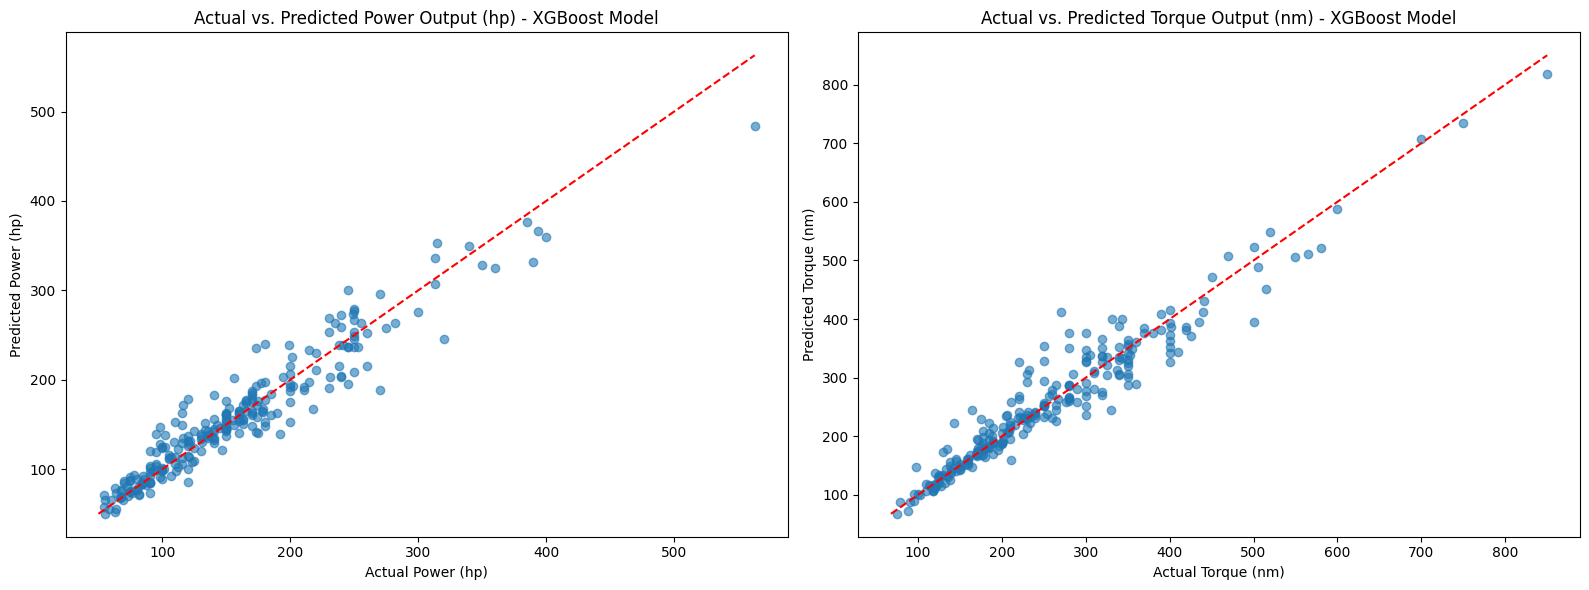

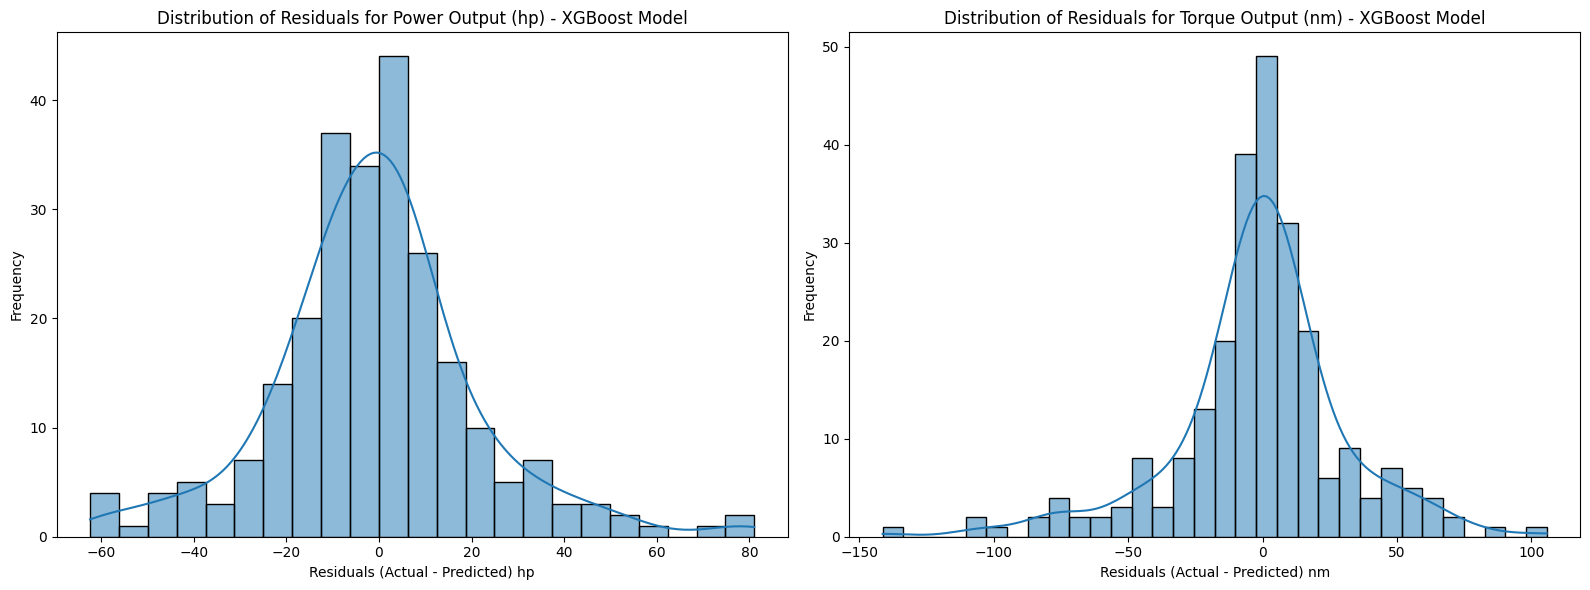

In [142]:
# Extract actual and predicted values for plotting
actual_power_xgb = Y_test.iloc[:, 0]
predicted_power_xgb = Y_pred_xgb[:, 0]
actual_torque_xgb = Y_test.iloc[:, 1]
predicted_torque_xgb = Y_pred_xgb[:, 1]

# Generate scatter plots for actual vs. predicted values
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot for Power Output (hp)
axes[0].scatter(actual_power_xgb, predicted_power_xgb, alpha=0.6)
axes[0].set_title('Actual vs. Predicted Power Output (hp) - XGBoost Model')
axes[0].set_xlabel('Actual Power (hp)')
axes[0].set_ylabel('Predicted Power (hp)')
min_val_power_xgb = min(actual_power_xgb.min(), predicted_power_xgb.min())
max_val_power_xgb = max(actual_power_xgb.max(), predicted_power_xgb.max())
axes[0].plot([min_val_power_xgb, max_val_power_xgb], [min_val_power_xgb, max_val_power_xgb], color='red', linestyle='--')

# Plot for Torque Output (nm)
axes[1].scatter(actual_torque_xgb, predicted_torque_xgb, alpha=0.6)
axes[1].set_title('Actual vs. Predicted Torque Output (nm) - XGBoost Model')
axes[1].set_xlabel('Actual Torque (nm)')
axes[1].set_ylabel('Predicted Torque (nm)')
min_val_torque_xgb = min(actual_torque_xgb.min(), predicted_torque_xgb.min())
max_val_torque_xgb = max(actual_torque_xgb.max(), predicted_torque_xgb.max())
axes[1].plot([min_val_torque_xgb, max_val_torque_xgb], [min_val_torque_xgb, max_val_torque_xgb], color='red', linestyle='--')

plt.tight_layout()
plt.show()

# Calculate residuals
residuals_power_xgb = actual_power_xgb - predicted_power_xgb
residuals_torque_xgb = actual_torque_xgb - predicted_torque_xgb

# Create histograms for residuals
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram for Power Output Residuals (XGBoost Model)
sns.histplot(residuals_power_xgb, kde=True, ax=axes[0])
axes[0].set_title('Distribution of Residuals for Power Output (hp) - XGBoost Model')
axes[0].set_xlabel('Residuals (Actual - Predicted) hp')
axes[0].set_ylabel('Frequency')

# Histogram for Torque Output Residuals (XGBoost Model)
sns.histplot(residuals_torque_xgb, kde=True, ax=axes[1])
axes[1].set_title('Distribution of Residuals for Torque Output (nm) - XGBoost Model')
axes[1].set_xlabel('Residuals (Actual - Predicted) nm')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

### We can see a huge improvement, The XGBoost model has a R2 score of 0.92, which is really great. We  will see later a comparison between all the models to find out which one is the best for the final steps.
### Let's test to implement a LightGBM model and see if it improves our results.

In [143]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean'))
])

categorical_transformer = Pipeline(steps=[
    ('string_converter', FunctionTransformer(lambda x: x.astype(str), validate=False)),
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

preprocessor.set_output(transform="pandas")

def clean_col_names(df):
    df_copy = df.copy()
    cols = df_copy.columns
    new_cols = []
    seen_names = {}
    for col in cols:
        cleaned_col = col.lower()
        cleaned_col = re.sub(r'[[\\]<>:\t| ,./()]', '_', cleaned_col)
        cleaned_col = re.sub(r'[^a-z0-9_]+', '', cleaned_col)

        original_cleaned_col = cleaned_col
        counter = 1
        while cleaned_col in seen_names:
            cleaned_col = f"{original_cleaned_col}_{counter}"
            counter += 1
        seen_names[cleaned_col] = True
        new_cols.append(cleaned_col)

    df_copy.columns = new_cols
    return df_copy

# Create a pipeline that first applies the preprocessor and then trains the MultiOutputRegressor with LGBMRegressor
lightgbm_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('name_cleaner', FunctionTransformer(clean_col_names, validate=False)),
    ('multioutputregressor', MultiOutputRegressor(estimator=lgb.LGBMRegressor(random_state=42)))
])

lightgbm_pipeline.fit(X_train, Y_train)

Y_pred_lgbm = lightgbm_pipeline.predict(X_test)

# Evaluate the model's performance
mae_lgbm = mean_absolute_error(Y_test, Y_pred_lgbm)
mse_lgbm = mean_squared_error(Y_test, Y_pred_lgbm)
r2_lgbm = r2_score(Y_test, Y_pred_lgbm)

print("LightGBM Regressor Model Performance (with advanced preprocessing):")
print(f"Mean Absolute Error (MAE): {mae_lgbm:.2f}")
print(f"Mean Squared Error (MSE): {mse_lgbm:.2f}")
print(f"R² Score: {r2_lgbm:.3f}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000503 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 918
[LightGBM] [Info] Number of data points in the train set: 993, number of used features: 76
[LightGBM] [Info] Start training from score 161.962739
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000078 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 918
[LightGBM] [Info] Number of data points in the train set: 993, number of used features: 76
[LightGBM] [Info] Start training from score 258.525680
LightGBM Regressor Model Performance (with advanced preprocessing):
Mean Absolute Error (MAE): 23.52
Mean Squared Error (MSE): 1469.45
R² Score: 0.864


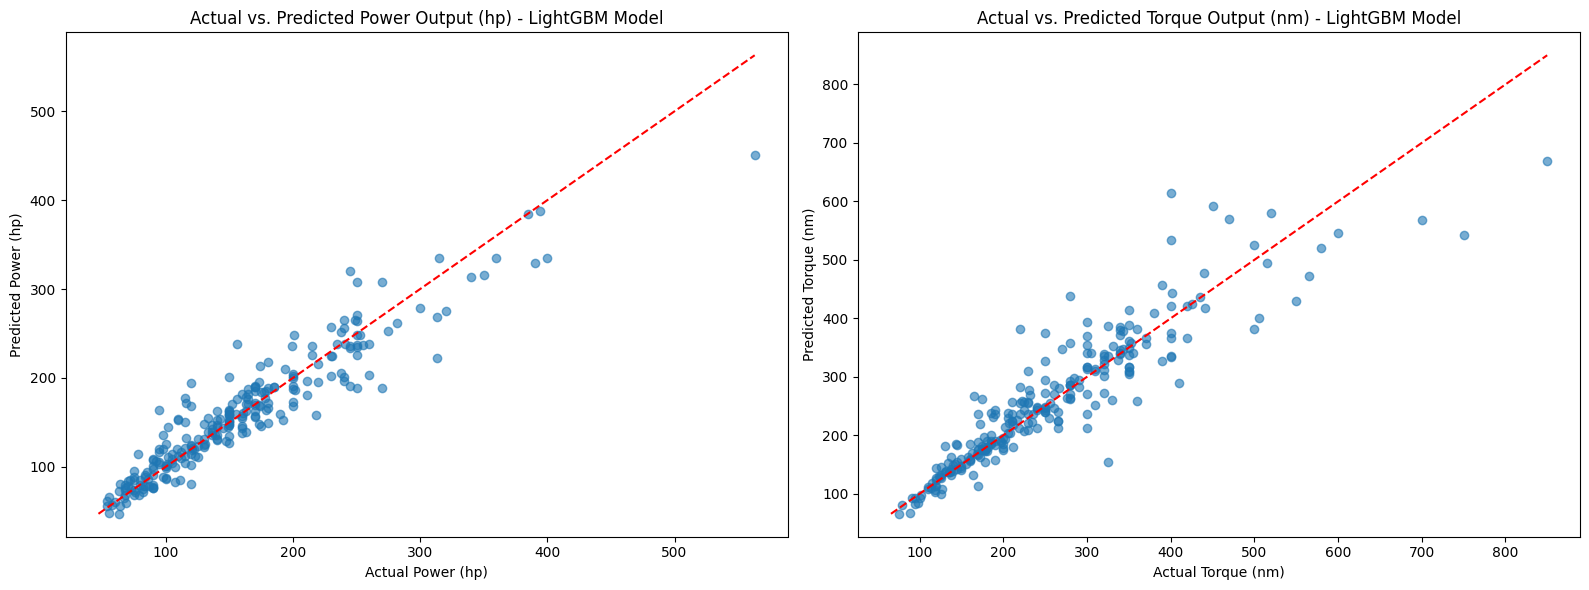

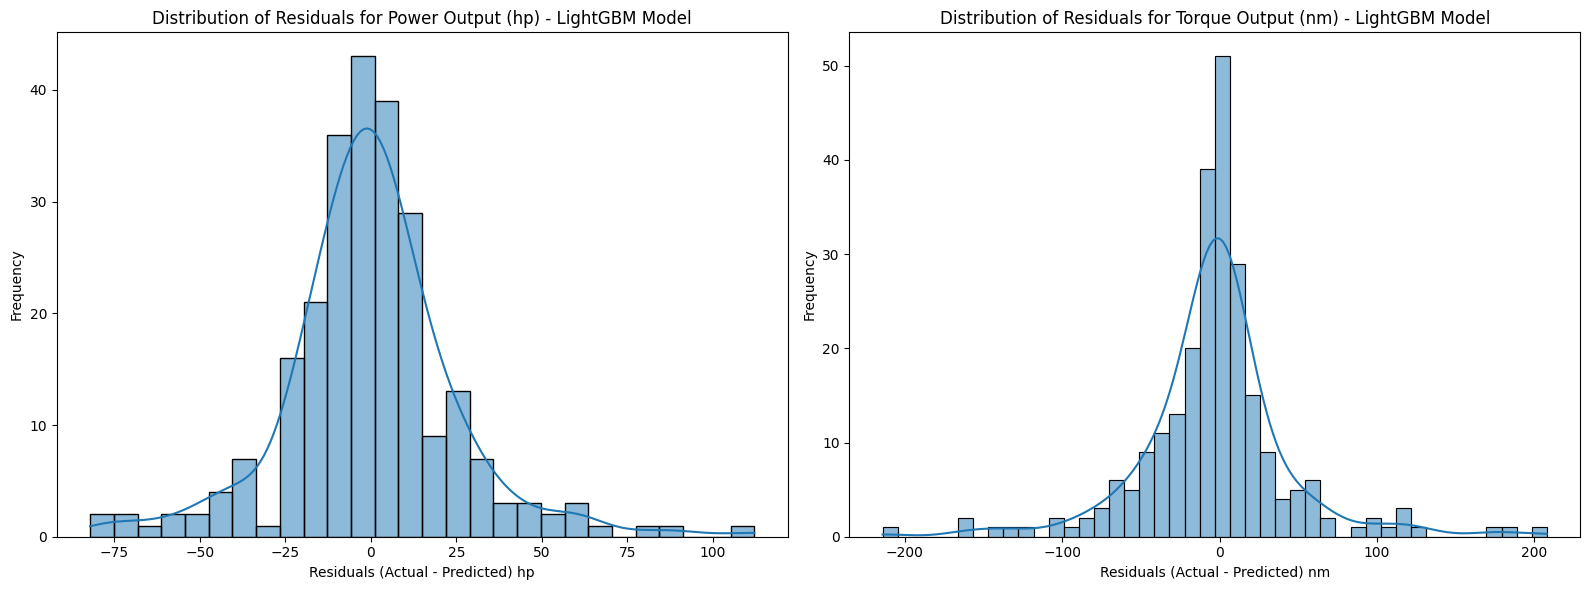

In [144]:
# Extract actual and predicted values for plotting
actual_power_lgbm = Y_test.iloc[:, 0]
predicted_power_lgbm = Y_pred_lgbm[:, 0]
actual_torque_lgbm = Y_test.iloc[:, 1]
predicted_torque_lgbm = Y_pred_lgbm[:, 1]
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot for Power Output (hp)
axes[0].scatter(actual_power_lgbm, predicted_power_lgbm, alpha=0.6)
axes[0].set_title('Actual vs. Predicted Power Output (hp) - LightGBM Model')
axes[0].set_xlabel('Actual Power (hp)')
axes[0].set_ylabel('Predicted Power (hp)')
min_val_power_lgbm = min(actual_power_lgbm.min(), predicted_power_lgbm.min())
max_val_power_lgbm = max(actual_power_lgbm.max(), predicted_power_lgbm.max())
axes[0].plot([min_val_power_lgbm, max_val_power_lgbm], [min_val_power_lgbm, max_val_power_lgbm], color='red', linestyle='--')

# Plot for Torque Output (nm)
axes[1].scatter(actual_torque_lgbm, predicted_torque_lgbm, alpha=0.6)
axes[1].set_title('Actual vs. Predicted Torque Output (nm) - LightGBM Model')
axes[1].set_xlabel('Actual Torque (nm)')
axes[1].set_ylabel('Predicted Torque (nm)')
min_val_torque_lgbm = min(actual_torque_lgbm.min(), predicted_torque_lgbm.min())
max_val_torque_lgbm = max(actual_torque_lgbm.max(), predicted_torque_lgbm.max())
axes[1].plot([min_val_torque_lgbm, max_val_torque_lgbm], [min_val_torque_lgbm, max_val_torque_lgbm], color='red', linestyle='--')

plt.tight_layout()
plt.show()
residuals_power_lgbm = actual_power_lgbm - predicted_power_lgbm
residuals_torque_lgbm = actual_torque_lgbm - predicted_torque_lgbm
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram for Power Output Residuals (LightGBM Model)
sns.histplot(residuals_power_lgbm, kde=True, ax=axes[0])
axes[0].set_title('Distribution of Residuals for Power Output (hp) - LightGBM Model')
axes[0].set_xlabel('Residuals (Actual - Predicted) hp')
axes[0].set_ylabel('Frequency')

# Histogram for Torque Output Residuals (LightGBM Model)
sns.histplot(residuals_torque_lgbm, kde=True, ax=axes[1])
axes[1].set_title('Distribution of Residuals for Torque Output (nm) - LightGBM Model')
axes[1].set_xlabel('Residuals (Actual - Predicted) nm')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

###Comparison of all models performance :



In [145]:
# Print all metrics from all models
metrics = {
    'Model': [
        'Baseline RF',
        'Tuned RF',
        'HistGradientBoosting',
        'Tuned RF + FE',
        'XGBoost',
        'LightGBM'
    ],
    'MAE': [
        mae, mae_tuned, mae_hgb, mae_fe, mae_xgb, mae_lgbm
    ],
    'MSE': [
        mse, mse_tuned, mse_hgb, mse_fe, mse_xgb, mse_lgbm
    ],
    'R2 Score': [
        r2, r2_tuned, r2_hgb, r2_fe, r2_xgb, r2_lgbm
    ]
}

metrics_df = pd.DataFrame(metrics)

print("Model Performance Metrics:")
display(metrics_df)


Model Performance Metrics:


,Model,MAE,MSE,R2 Score
0,Baseline RF,33.241932,6094.162307,0.624094
1,Tuned RF,20.644265,1000.796120,0.898191
2,HistGradientBoosting,22.515175,1375.363047,0.873183
3,Tuned RF + FE,20.699920,1022.655632,0.895978
4,XGBoost,18.636862,756.031128,0.921147
5,LightGBM,23.521711,1469.454041,0.863665


### Let's plot all these metrics in order to see clearly which one is the best model.

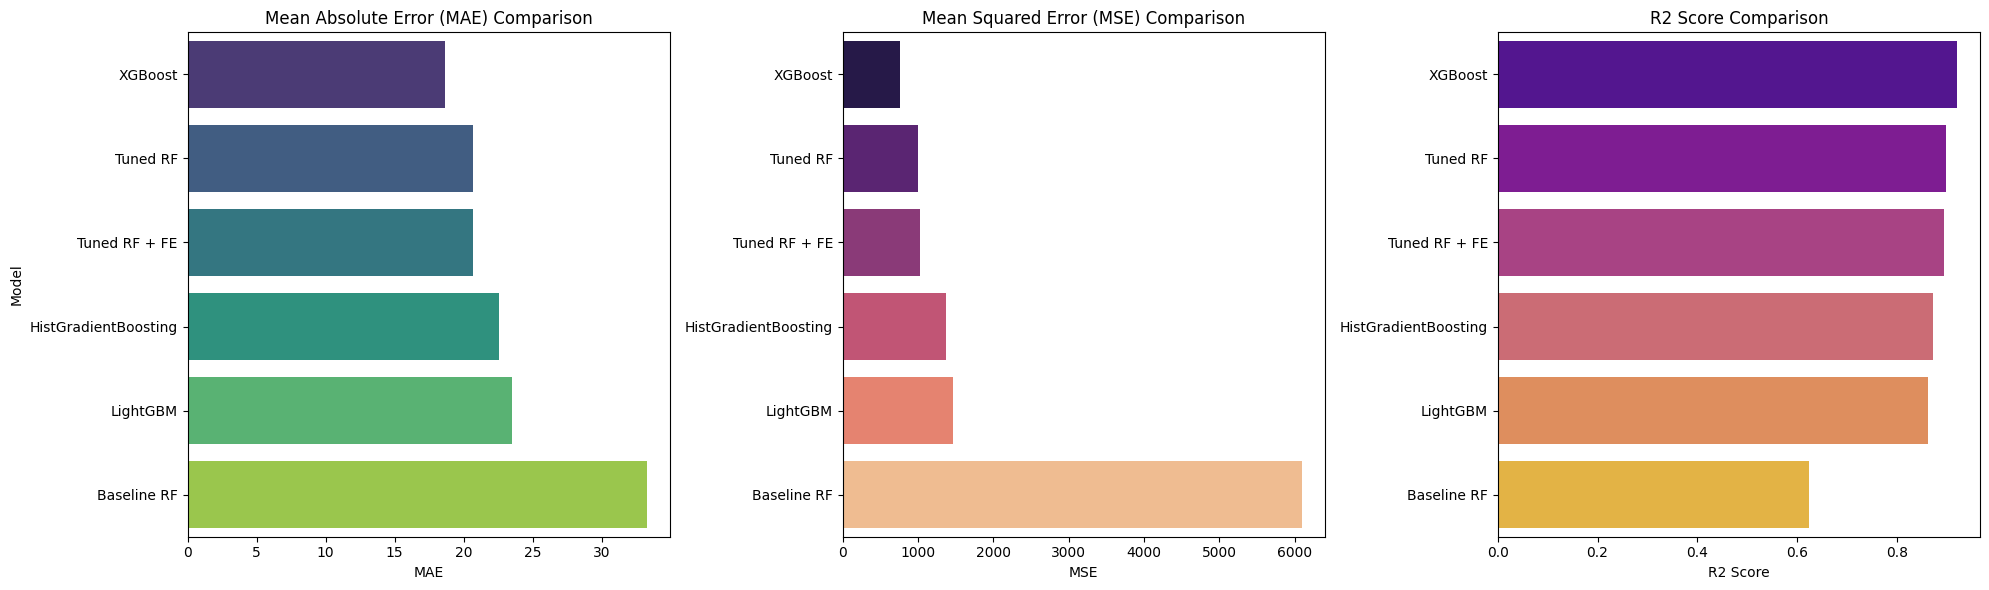

In [146]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Plot for MAE
mae_df = metrics_df.sort_values(by='MAE', ascending=True)
sns.barplot(x='MAE', y='Model', data=mae_df, ax=axes[0], palette='viridis', hue='Model', legend=False)
axes[0].set_title('Mean Absolute Error (MAE) Comparison')
axes[0].set_xlabel('MAE')
axes[0].set_ylabel('Model')

# Plot for MSE
mse_df = metrics_df.sort_values(by='MSE', ascending=True)
sns.barplot(x='MSE', y='Model', data=mse_df, ax=axes[1], palette='magma', hue='Model', legend=False)
axes[1].set_title('Mean Squared Error (MSE) Comparison')
axes[1].set_xlabel('MSE')
axes[1].set_ylabel('') # Remove y-label for better readability

# Plot for R2 Score
r2_df = metrics_df.sort_values(by='R2 Score', ascending=False)
sns.barplot(x='R2 Score', y='Model', data=r2_df, ax=axes[2], palette='plasma', hue='Model', legend=False)
axes[2].set_title('R2 Score Comparison')
axes[2].set_xlabel('R2 Score')
axes[2].set_ylabel('') # Remove y-label for better readability

plt.tight_layout()
plt.show()

### After looking at the plot we can clearly see that the XGBoost model is the best. It has the best R2 score and less errors than other models.
### We will now predict the power and torque for one specific motor and see if the model is accurate.

In [147]:
# You can change the index (e.g., 5) to pick a different engine from the dataset
selected_engine_index = 4

actual_engine_data = df_final.loc[selected_engine_index].drop(columns=['power output, hp', 'torque output, nm'])

new_engine_specifications = actual_engine_data.to_dict()

actual_power_hp = df_final.loc[selected_engine_index, 'power output, hp']
actual_torque_nm = df_final.loc[selected_engine_index, 'torque output, nm']
new_engine_df = pd.DataFrame([new_engine_specifications])

new_engine_df = new_engine_df.reindex(columns=X_train.columns, fill_value=None)

print("Engine specifications for prediction:")
display(new_engine_df)


Engine specifications for prediction:


,id,"cylinder bore, mm","piston stroke, mm",compression ratio,"engine oil capacity, liter","engine lifespan, km","weight, kg",production_start,production_end,Title,...,cylinder block,block head,features,hydraulic lifters,timing drive,phase regulator,turbocharging,recommended engine oil,fuel type,euro standards
0,5,84.5,89.0,10.5,6.5,240.0,NaN,2009.0,2013.0,Engine Audi CGWA,...,aluminum v6,aluminum 24v,dohc,yes,4 chains,on the intake shafts,compressor,5w-30,petrol,euro 5


In [148]:
# Perform prediction with the XGBoost model
X_new_engine_transformed = xgboost_pipeline.named_steps['preprocessor'].transform(new_engine_df)

# Predict using only the multioutputregressor part of the pipeline
Y_pred_new_engine = xgboost_pipeline.named_steps['multioutputregressor'].predict(X_new_engine_transformed)

predicted_power = Y_pred_new_engine[0, 0]
predicted_torque = Y_pred_new_engine[0, 1]

print("\n--- Prediction Results ---")
print(f"Predicted Power (hp): {predicted_power:.2f}")
print(f"Predicted Torque (nm): {predicted_torque:.2f}")

if actual_power_hp is not None:
    print(f"\n--- Comparison with Actual Values (if provided) ---")
    print(f"Actual Power (hp): {actual_power_hp:.2f}")
    print(f"Power Difference: {predicted_power - actual_power_hp:.2f} hp")

if actual_torque_nm is not None:
    print(f"Actual Torque (nm): {actual_torque_nm:.2f}")
    print(f"Torque Difference: {predicted_torque - actual_torque_nm:.2f} nm")



--- Prediction Results ---
Predicted Power (hp): 286.29
Predicted Torque (nm): 419.92

--- Comparison with Actual Values (if provided) ---
Actual Power (hp): 290.00
Power Difference: -3.71 hp
Actual Torque (nm): 420.00
Torque Difference: -0.08 nm


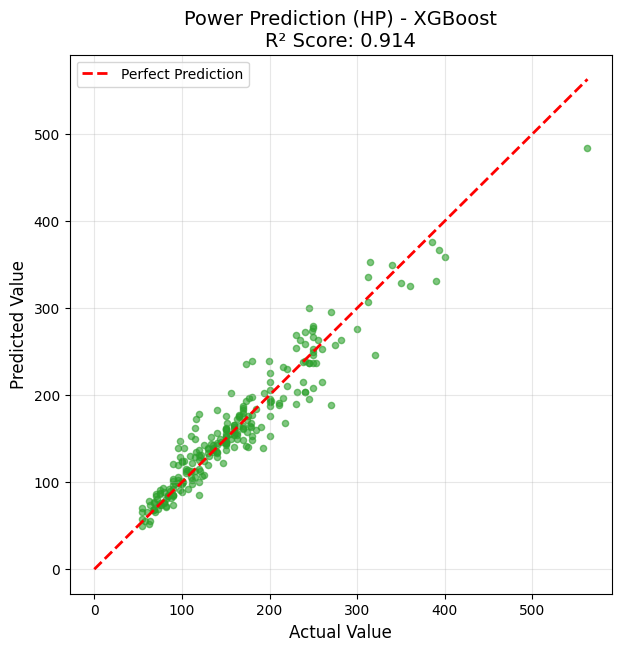

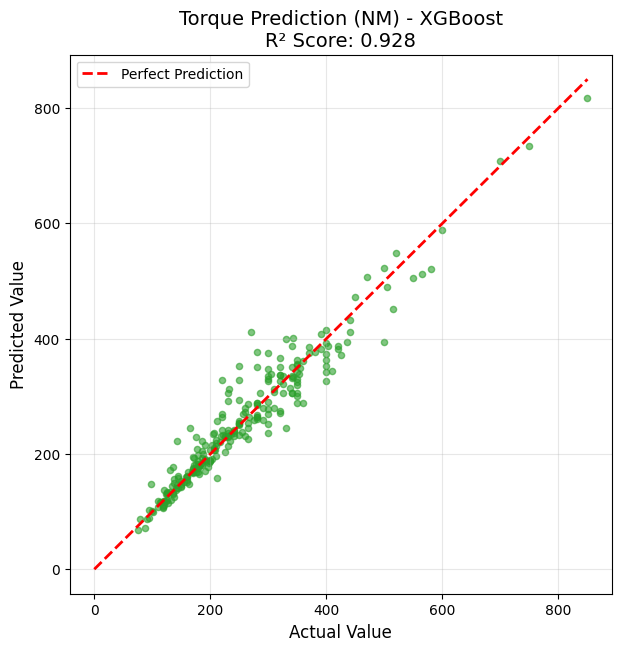

In [149]:
# Final visualisation
def plot_results(y_true, y_pred, title, r2):
    plt.figure(figsize=(7, 7))
    plt.scatter(y_true, y_pred, alpha=0.6, color='#2ca02c', s=20)

    # Perfect Prediction Line
    m = max(y_true.max(), y_pred.max())
    plt.plot([0, m], [0, m], 'r--', lw=2, label='Perfect Prediction')

    plt.title(f"{title}\nR² Score: {r2:.3f}", fontsize=14)
    plt.xlabel("Actual Value", fontsize=12)
    plt.ylabel("Predicted Value", fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Calculate individual R2 scores for power and torque for the XGBoost model
r2_power_xgb = r2_score(Y_test.iloc[:, 0], Y_pred_xgb[:, 0])
r2_torque_xgb = r2_score(Y_test.iloc[:, 1], Y_pred_xgb[:, 1])

# Plot Power Results using XGBoost predictions
plot_results(Y_test.iloc[:, 0], Y_pred_xgb[:, 0], "Power Prediction (HP) - XGBoost", r2_power_xgb)

# Plot Torque Results using XGBoost predictions
plot_results(Y_test.iloc[:, 1], Y_pred_xgb[:, 1], "Torque Prediction (NM) - XGBoost", r2_torque_xgb)